# LETID Outdoor Geospatial Demo (HPC)

![PVDeg Logo](../images/pvdeg_logo.svg)

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pvdeg
from pvdeg import DATA_DIR
import os

In [2]:
# This information helps with debugging and getting support :)
import sys
import platform

print("Working on a ", platform.system(), platform.release())
print("Python version ", sys.version)
print("Pandas version ", pd.__version__)
print("pvdeg version ", pvdeg.__version__)

Working on a  Linux 4.18.0-477.10.1.el8_8.x86_64
Python version  3.13.14 | packaged by Anaconda, Inc. | (main, Jun 17 2026, 20:12:46) [GCC 14.3.0]
Pandas version  3.0.3
pvdeg version  0.7.2.dev4+g321beb370


# Single location example

In [3]:
weather_file = os.path.join(DATA_DIR, "psm3_demo.csv")
WEATHER, META = pvdeg.weather.read(weather_file, "psm")

In [4]:
kwargs = {
    "tau_0": 115,  # us, carrier lifetime in non-degraded states, e.g. LETID/LID states A or C
    "tau_deg": 55,  # us, carrier lifetime in fully-degraded state, e.g. LETID/LID state B
    "wafer_thickness": 180,  # um
    "s_rear": 46,  # cm/s
    "cell_area": 243,  # cm^2
    "na_0": 100,
    "nb_0": 0,
    "nc_0": 0,
    "mechanism_params": "D037",
}

In [5]:
pvdeg.letid.calc_letid_outdoors(weather_df=WEATHER, meta=META, **kwargs)

/projects/pvdeg/mspringe/envs/pvdeg_313/lib/python3.13/site-packages/scipy/optimize/_chandrupatla.py:437: RuntimeWarning: invalid value encountered in divide
  C = A / (A + B)


,Temperature,Injection,NA,NB,NC,tau,Jsc,Voc,Isc,FF,Pmp,Pmp_norm
time,,,,,,,,,,,,
1999-01-01 00:30:00-07:00,0.0,NaN,100.000000,0.000000e+00,0.000000e+00,115.000000,41.590997,0.666327,10.106612,0.840987,5.663467,1.000000
1999-01-01 01:30:00-07:00,0.0,NaN,100.000000,1.702422e-15,0.000000e+00,115.000000,41.590997,0.666327,10.106612,0.840987,5.663467,1.000000
1999-01-01 02:30:00-07:00,0.0,NaN,100.000000,3.404843e-15,5.403329e-36,115.000000,41.590997,0.666327,10.106612,0.840987,5.663467,1.000000
1999-01-01 03:30:00-07:00,0.0,NaN,100.000000,5.107265e-15,1.620999e-35,115.000000,41.590997,0.666327,10.106612,0.840987,5.663467,1.000000
1999-01-01 04:30:00-07:00,0.0,NaN,100.000000,6.809686e-15,3.241997e-35,115.000000,41.590997,0.666327,10.106612,0.840987,5.663467,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
1999-12-31 19:30:00-07:00,0.0,NaN,27.833654,6.778463e+01,4.381716e+00,66.112142,41.333851,0.654974,10.044126,0.838966,5.519257,0.974537
1999-12-31 20:30:00-07:00,0.0,NaN,27.833654,6.778463e+01,4.381716e+00,66.112142,41.333851,0.654974,10.044126,0.838966,5.519257,0.974537
1999-12-31 21:30:00-07:00,0.0,NaN,27.833654,6.778463e+01,4.381716e+00,66.112142,41.333851,0.654974,10.044126,0.838966,5.519257,0.974537


# Start distributed compute cluster - DASK

In [6]:
local = {
    "manager": "local",
    "n_workers": 1,
    "threads_per_worker": 8,  # Number of CPUs
}

# kestrel = {
#     "manager": "slurm",
#     "n_jobs": 1,  # Number of nodes used for parallel processing
#     "cores": 104,
#     "memory": "230GB",
#     "account": "pvdeg",
#     "queue": "debug",
#     "walltime": "1:00:00",
#     "processes": 104,
#     "job_extra_directives": ["-o ./logs/slurm-%j.out"],
# }

kestrel = {
    "manager": "slurm",
    "n_jobs": 1,  # Number of nodes used for parallel processing
    "cores": 100,
    "memory": "230GB",
    "account": "pvdeg",
    "queue": "debug",
    "walltime": "1:00:00",
    "interface": "hsn0",
    "processes": 100,  # workers per node; 104 single-thread procs overwhelm startup
    "local_directory": "/scratch/mspringe/",  # node-local scratch for fast worker startup
    "death_timeout": 600,  # secs a worker waits to reach the scheduler before exiting
    "job_extra_directives": ["-o ./logs/slurm-%j.out"],
}

pvdeg.geospatial.start_dask(hpc=kestrel)

/projects/pvdeg/mspringe/envs/pvdeg_313/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41859 instead
  warnings.warn(


Dashboard: http://10.150.0.18:41859/status


Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://10.150.0.18:41859/status,
Dashboard: http://10.150.0.18:41859/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.150.0.18:45315,Workers: 0
Dashboard: http://10.150.0.18:41859/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [7]:
# Get weather data
weather_db = "NSRDB"

weather_arg = {
    "satellite": "Americas",
    "names": 2022,
    "NREL_HPC": True,
    "attributes": [
        "air_temperature",
        "wind_speed",
        "dhi",
        "ghi",
        "dni",
        "relative_humidity",
    ],
}

weather_ds, meta_df = pvdeg.weather.get(weather_db, geospatial=True, **weather_arg)

# Define geographical region
meta_SW = meta_df[meta_df["State"].isin(["Colorado", "New Mexico", "Utah", "Arizona"])]
meta_SW_sub, gids_SW_sub = pvdeg.utilities.gid_downsampling(meta_SW, 6)

# Chunk along gid so geospatial.analysis (weather_ds.map_blocks) emits one task per
# location instead of a single serial block. time stays one chunk (-1) because each
# location needs its full timeseries.
weather_SW_sub = weather_ds.sel(gid=meta_SW_sub.index).chunk({"time": -1, "gid": 1})

/kfs2/projects/pvdeg/mspringe/repos/PVDegradationTools/pvdeg/weather.py:556: UserWarning: The specified chunks separate the stored chunks along dimension "phony_dim_1" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(


In [8]:
weather_SW_sub

<xarray.Dataset> Size: 409MB
Dimensions:            (time: 17520, gid: 486)
Coordinates:
  * time               (time) datetime64[us] 140kB 2022-01-01 ... 2022-12-31T...
  * gid                (gid) int64 4kB 277461 277473 277485 ... 554496 554508
Data variables:
    temp_air           (time, gid) float64 68MB dask.array<chunksize=(17520, 1), meta=np.ndarray>
    wind_speed         (time, gid) float64 68MB dask.array<chunksize=(17520, 1), meta=np.ndarray>
    dhi                (time, gid) float64 68MB dask.array<chunksize=(17520, 1), meta=np.ndarray>
    ghi                (time, gid) float64 68MB dask.array<chunksize=(17520, 1), meta=np.ndarray>
    dni                (time, gid) float64 68MB dask.array<chunksize=(17520, 1), meta=np.ndarray>
    relative_humidity  (time, gid) float64 68MB dask.array<chunksize=(17520, 1), meta=np.ndarray>
Attributes:
    full_version_record:   {"rex": "0.2.80", "pandas": "2.0.0", "numpy": "1.2...
    package:               rex
    version:               4.0.0
    kestrel_nsrdb_fnames:  ['/datasets/NSRDB/current/nsrdb_2022.h5']

In [9]:
meta_df

,latitude,longitude,altitude,tz,Country,State,County,wind_height
0,-15.950000,-179.979996,0,12,NaN,NaN,NaN,2
1,-15.990000,-179.979996,0,12,NaN,NaN,NaN,2
2,-16.030001,-179.979996,0,12,NaN,NaN,NaN,2
3,-16.070000,-179.979996,0,12,NaN,NaN,NaN,2
4,-16.110001,-179.979996,0,12,NaN,NaN,NaN,2
...,...,...,...,...,...,...,...,...
2018262,16.010000,-22.500000,0,-1,NaN,NaN,NaN,2
2018263,15.970000,-22.500000,0,-1,NaN,NaN,NaN,2
2018264,15.930000,-22.500000,0,-1,NaN,NaN,NaN,2
2018265,15.890000,-22.500000,0,-1,NaN,NaN,NaN,2


In [10]:
# Define desired analysis
geo = {
    "func": pvdeg.letid.calc_letid_outdoors,
    "weather_ds": weather_SW_sub,
    "meta_df": meta_SW_sub,
    "tau_0": 115,  # us, carrier lifetime in non-degraded states, e.g. LETID/LID states A or C
    "tau_deg": 55,  # us, carrier lifetime in fully-degraded state, e.g. LETID/LID state B
    "wafer_thickness": 180,  # um
    "s_rear": 46,  # cm/s
    "cell_area": 243,  # cm^2
    "na_0": 100,
    "nb_0": 0,
    "nc_0": 0,
    "mechanism_params": "D037",
}

letid_res = pvdeg.geospatial.analysis(**geo)

/projects/pvdeg/mspringe/envs/pvdeg_313/lib/python3.13/site-packages/distributed/client.py:3429: UserWarning: Sending large graph of size 11.19 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/kfs2/projects/pvdeg/mspringe/repos/PVDegradationTools/pvdeg/utilities.py:1567: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  stacked = ds_gids.drop(["gid"])


In [11]:
letid_res

<xarray.Dataset> Size: 962MB
Dimensions:      (latitude: 22, longitude: 26, time: 17520)
Coordinates:
  * latitude     (latitude) float32 88B 31.81 32.29 32.77 ... 40.93 41.41 41.89
  * longitude    (longitude) float32 104B -114.3 -113.8 -113.3 ... -102.8 -102.3
  * time         (time) datetime64[us] 140kB 2022-01-01 ... 2022-12-31T23:30:00
Data variables:
    Voc          (time, latitude, longitude) float64 80MB nan nan ... nan nan
    Isc          (time, latitude, longitude) float64 80MB nan nan ... nan nan
    NA           (time, latitude, longitude) float64 80MB nan nan ... nan nan
    Injection    (time, latitude, longitude) float64 80MB nan nan ... nan nan
    Pmp          (time, latitude, longitude) float64 80MB nan nan ... nan nan
    tau          (time, latitude, longitude) float64 80MB nan nan ... nan nan
    Pmp_norm     (time, latitude, longitude) float64 80MB nan nan ... nan nan
    NB           (time, latitude, longitude) float64 80MB nan nan ... nan nan
    Temperature  (time, latitude, longitude) float64 80MB nan nan ... nan nan
    FF           (time, latitude, longitude) float64 80MB nan nan ... nan nan
    NC           (time, latitude, longitude) float64 80MB nan nan ... nan nan
    Jsc          (time, latitude, longitude) float64 80MB nan nan ... nan nan

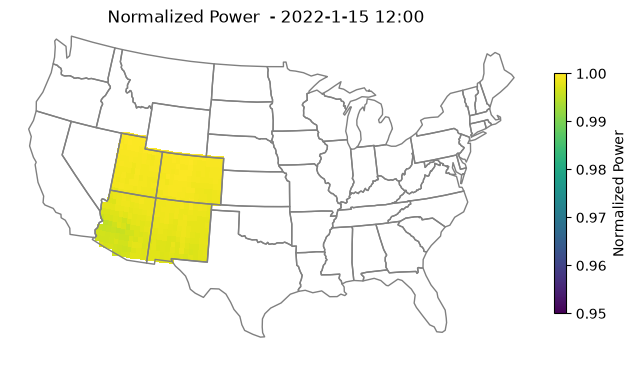

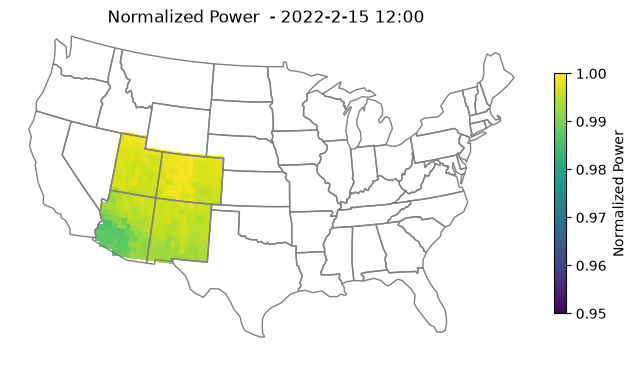

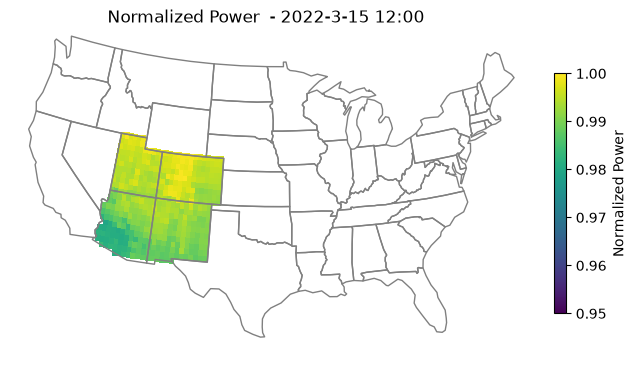

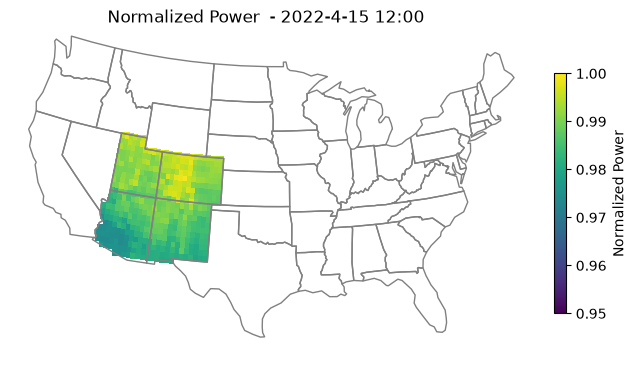

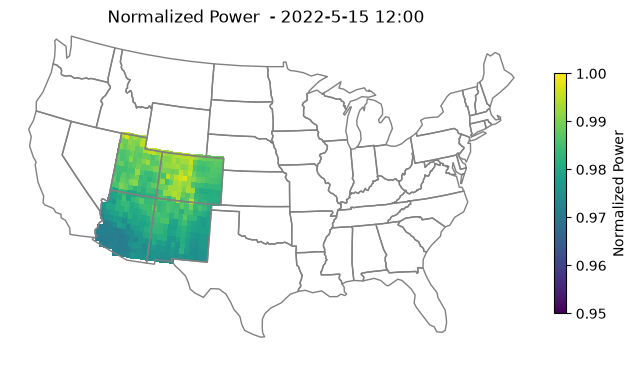

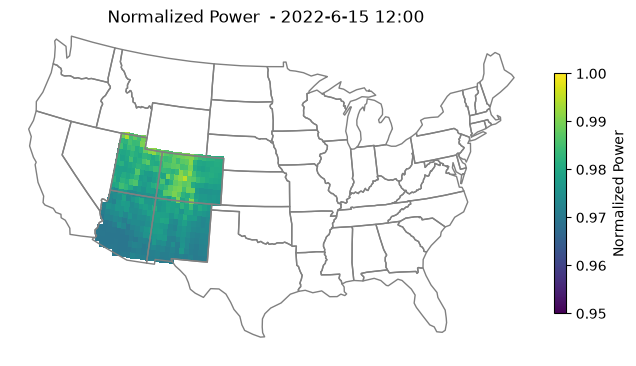

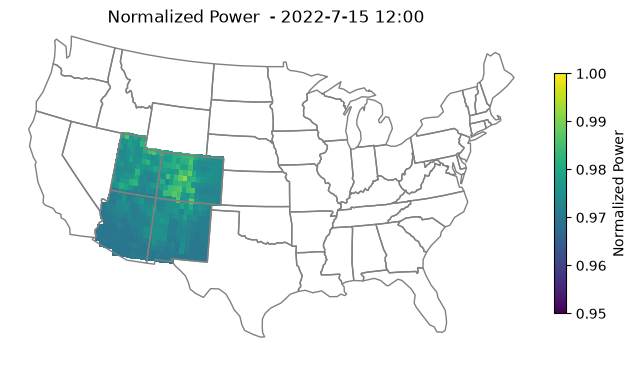

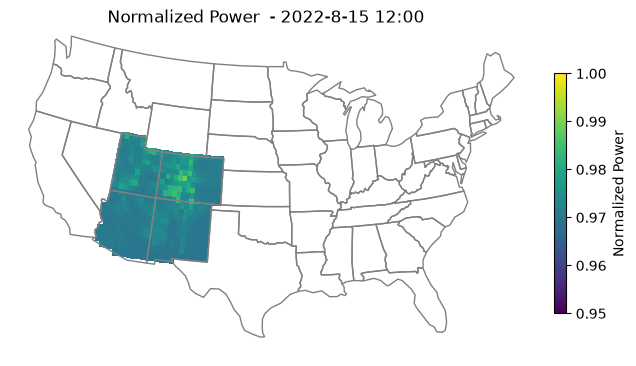

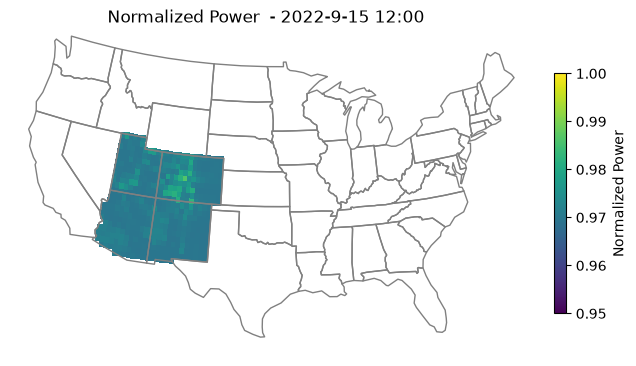

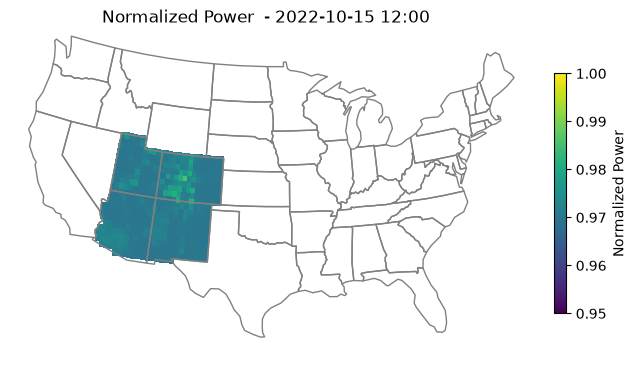

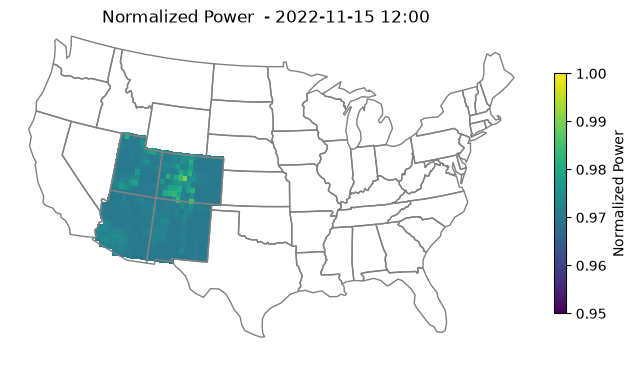

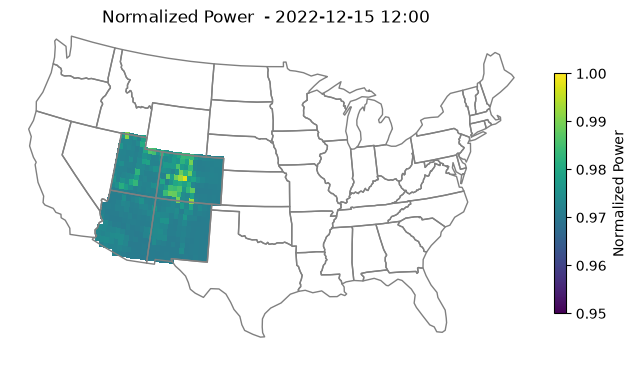

In [16]:
import datetime

ims = []
for n in range(1, 13):
    for i, np_t in enumerate(letid_res.time):
        t = pd.Timestamp(np_t.values).time()
        d = pd.Timestamp(np_t.values).day
        m = pd.Timestamp(np_t.values).month
        if m == n:
            if d == 15:
                if t == datetime.time(12):
                    fig, ax = pvdeg.geospatial.plot_USA(
                        letid_res["Pmp_norm"].sel(time=np_t),
                        cmap="viridis",
                        vmin=0.95,
                        vmax=1,
                        title=f"Normalized Power  - 2022-{m}-{d} 12:00",
                        cb_title="Normalized Power",
                    )
                    plt.savefig(f"../../TEMP/RH_animation_{n}.png", dpi=600)

# import imageio
# ims = [imageio.imread(f'../../TEMP/RH_animation_{n}.png') for n in range(1, 13)]
# imageio.mimwrite('../../TEMP/RH_animation.gif', ims, format='GIF', duration=1000, loop=10)

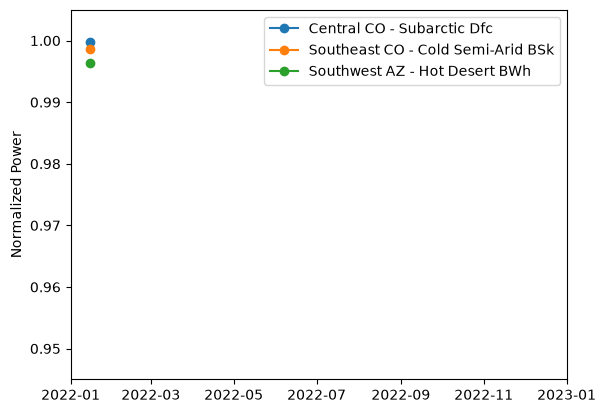

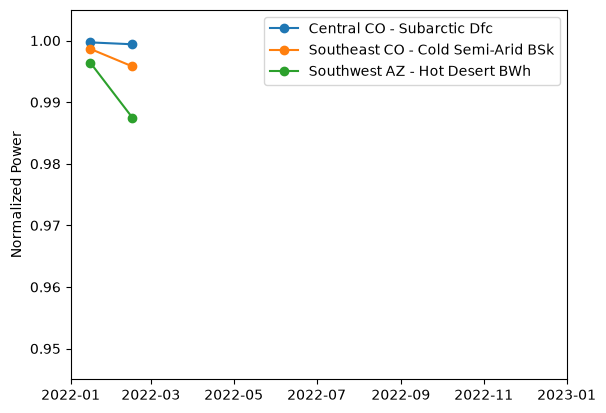

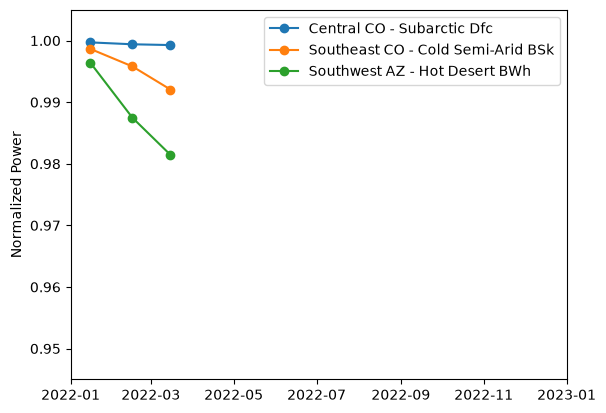

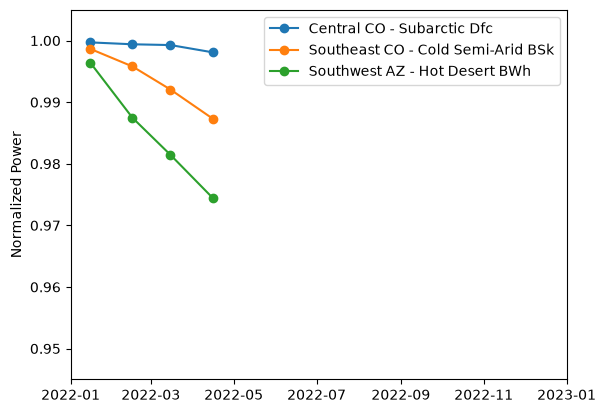

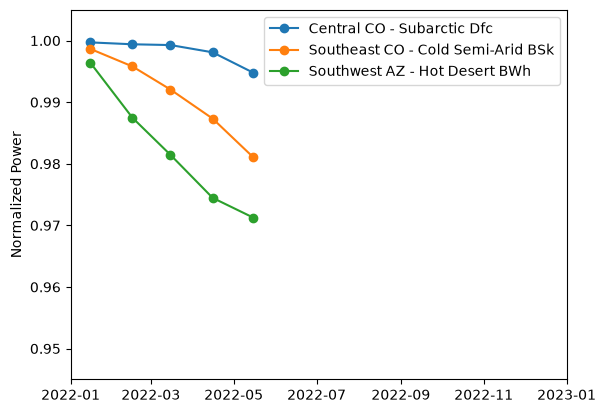

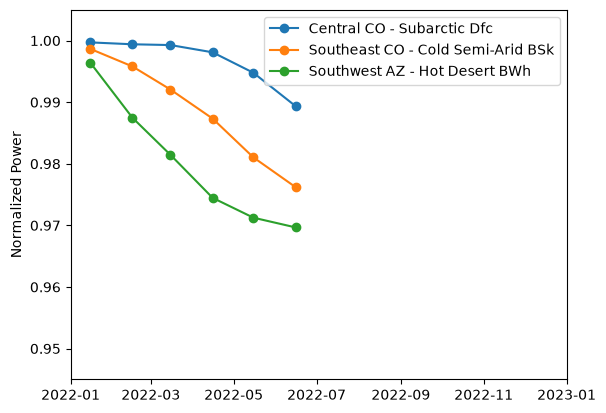

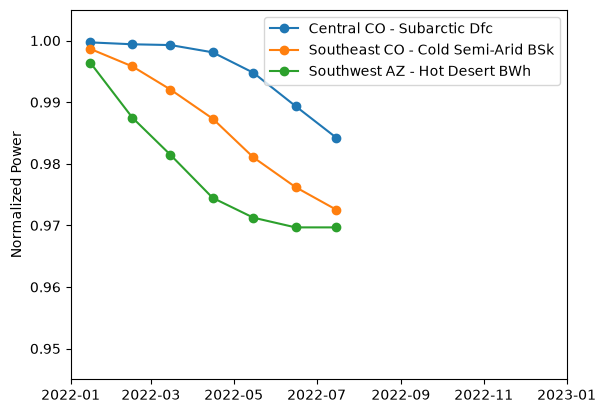

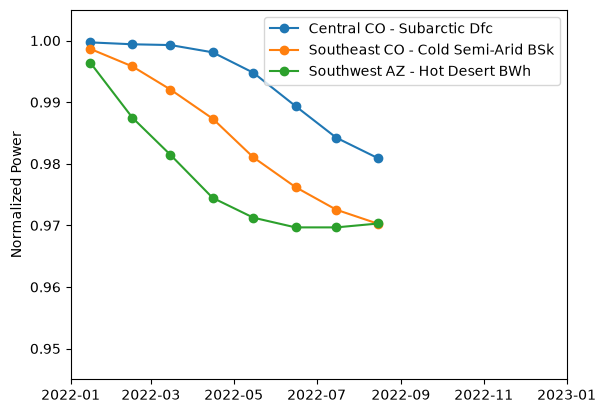

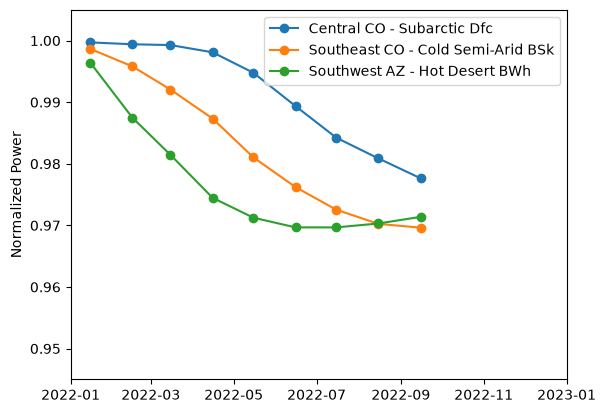

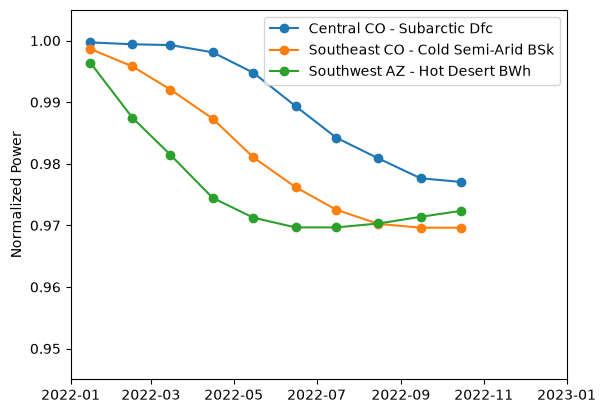

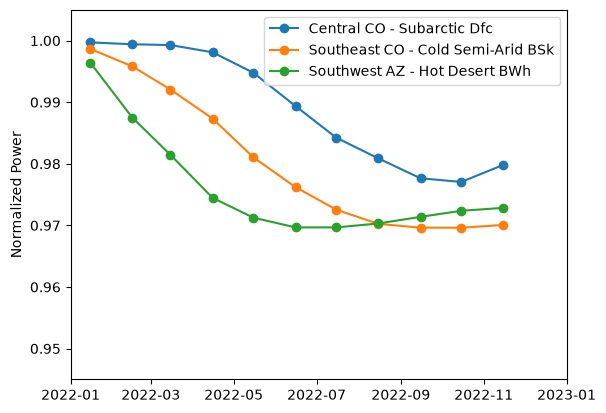

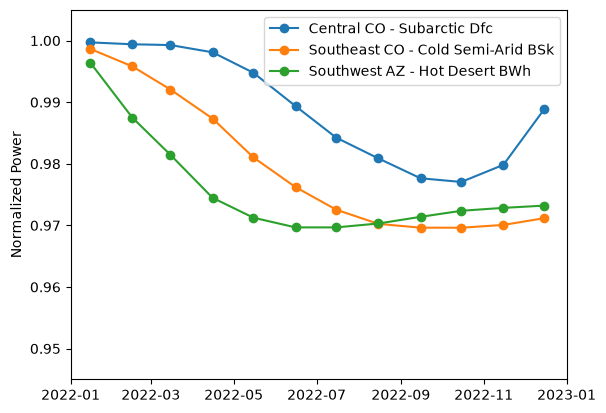

In [15]:
import datetime

ims = []
dates = []
subarctics = []
coldsemiarids = []
hotdeserts = []

for n in range(1, 13):
    for i, np_t in enumerate(letid_res.time):
        t = pd.Timestamp(np_t.values).time()
        d = pd.Timestamp(np_t.values).day
        m = pd.Timestamp(np_t.values).month
        if m == n:
            if d == 15:
                if t == datetime.time(12):
                    dates.append(np_t.values)

                    # subartic: near Crested Butte CO
                    # cold semi-arid: near Springfield CO
                    # hot desert: near Yuma AZ

                    subarctic = letid_res.sel(
                        time=np_t, latitude=39.01, longitude=-107.1
                    )
                    subarctics.append(subarctic["Pmp_norm"])

                    coldsemiarid = letid_res.sel(
                        time=np_t, latitude=37.57, longitude=-102.3
                    )
                    coldsemiarids.append(coldsemiarid["Pmp_norm"])

                    hotdesert = letid_res.sel(
                        time=np_t, latitude=32.77, longitude=-114.3
                    )
                    hotdeserts.append(hotdesert["Pmp_norm"])

                    fig, ax = plt.subplots()
                    ax.plot(
                        dates,
                        subarctics,
                        marker="o",
                        c="C0",
                        label="Central CO - Subarctic Dfc",
                    )
                    ax.plot(
                        dates,
                        coldsemiarids,
                        marker="o",
                        c="C1",
                        label="Southeast CO - Cold Semi-Arid BSk",
                    )
                    ax.plot(
                        dates,
                        hotdeserts,
                        marker="o",
                        c="C2",
                        label="Southwest AZ - Hot Desert BWh",
                    )

                    ax.legend(loc="upper right")

                    ax.set_xlim([datetime.date(2022, 1, 1), datetime.date(2023, 1, 1)])

                    ax.set_ylim([0.945, 1.005])
                    ax.set_ylabel("Normalized Power")

                    plt.savefig(f"../../TEMP/LETID_plot_animation_{n}.png", dpi=600)

In [ ]:
# import imageio

# ims = [imageio.imread(f"../../TEMP/LETID_plot_animation_{n}.png") for n in range(1, 13)]
# imageio.mimwrite(
#     "../../TEMP/LETID_plot_animation.gif", ims, format="GIF", duration=1000, loop=10
# )